# Análise Multivariada


## 1. Importação dos pacotes e funções

### 1.1 Bibliotecas utilizadas

In [36]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import FactorAnalysis, PCA
from factor_analyzer import FactorAnalyzer
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer


### 1.2 Configurações

In [2]:
#pd.options.display.max_columns = None 
#pd.options.display.max_rows = None
seed = 42
np.random.seed(seed)

### 1.3 Funções

In [12]:
def normalizador_min_max(dados, variaveis):
    
    for j in variaveis:
        menor = min(dados[str(j)]) 
        maior = max(dados[str(j)])
        
        dif = maior - menor
        if dif==0:
            dif=1 
        
        for i in range(dados.shape[0]):
            dados.loc[i,j] = (dados[str(j)][i]-menor)/ dif

    return(dados) 

In [17]:
def var_columns_to_drop(df, threshold = 0.006 ):
    #storing the variance and name of variables
    
    variance = df.var()
    columns = df.columns
    
    #saving the names of variables having variance more than a threshold value
    
    variable = [ ]
    
    for i in range(0,len(variance)):
        if variance[i]<= threshold:   #0.006 setting the threshold as 1%
            variable.append(columns[i])
            
    return(variable)   

In [22]:
def get_top_abs_correlations(df, n=5):
    au_corr = df.corr().abs().unstack()
    labels_to_drop = get_redundant_pairs(df)
    au_corr = au_corr.drop(labels=labels_to_drop).sort_values(ascending=False)
    return au_corr[0:n]

def get_redundant_pairs(df):
    '''Get diagonal and lower triangular pairs of correlation matrix'''
    pairs_to_drop = set()
    cols = df.columns
    for i in range(0, df.shape[1]):
        for j in range(0, i+1):
            pairs_to_drop.add((cols[i], cols[j]))
    return pairs_to_drop

In [27]:
def PCA_explicabilidade(dados, seed = 42):
    
    PCA = pca()
    
    X = dados
    n = len(dados.columns) + 1
    pca = PCA(n_components = 0.95)
    pca.fit(X)
    reduced = pca.transform(X)

    pca = PCA(random_state = seed).fit(X)

    %matplotlib inline
    plt.rcParams["figure.figsize"] = (12,6)

    fig, ax = plt.subplots()
    xi = np.arange(1, n, step=1)
    y = np.cumsum(pca.explained_variance_ratio_)

    plt.ylim(0.0,1.1)
    plt.plot(xi, y, marker='o', linestyle='--', color='b')

    plt.xlabel('Number of Components')
    plt.xticks(np.arange(0, n, step=1)) #change from 0-based array index to 1-based human-readable label
    plt.ylabel('Cumulative variance (%)')
    plt.title('The number of components needed to explain variance')

    plt.axhline(y=0.95, color='r', linestyle='-')
    plt.text(0.5, 0.85, '95% cut-off threshold', color = 'red', fontsize=16)

    ax.grid(axis='x')
    plt.show()

In [31]:
def PCA_elbow(dados, componentes = 10, seed = 42):
    X = dados
    pca = PCA(n_components= componentes, svd_solver = 'auto',random_state = seed)
    Principal_components=pca.fit_transform(X)
    pca_df = pd.DataFrame(data = Principal_components,
                          #columns = ['PC 1', 'PC 2', 'PC 3', 'PC 4', 'PC 5', 'PC 6']
                         )
    PC_values = np.arange(pca.n_components_) + 1
    plt.plot(PC_values, pca.explained_variance_ratio_, 'ro-', linewidth=2)
    plt.title('Scree Plot')
    plt.xlabel('Principal Component')
    plt.ylabel('Proportion of Variance Explained')
    plt.show()

In [ ]:
def elbow_kmeans(dados,n_maximo_clusters):

    wcss=[]

    for i in range(1,n_maximo_clusters): 
         wcss.append(KMeans(n_clusters=i, init ='k-means++', max_iter=300,  n_init=10,random_state=0 ).fit(dados).inertia_)

    plt.plot(range(1,n_maximo_clusters),wcss)
    plt.title('Gráfico do cotovelo')
    plt.xlabel('Quantidade de clusters')
    plt.ylabel('WCSS')
    plt.show()

## 2. Leitura dos Dados

In [56]:
df = pd.read_csv('coordenadas_mapeadas_variaveis.csv')

In [57]:
try:
    #del df['Unnamed: 0']
    del df['geometry']
    del df['index_right']
    del df['geom']
    del df['lat_ocr']
    del df['lon_ocr']
except:
    pass

In [9]:
print('A base possui', df.shape[0], 'linhas (coordenadas) e', df.shape[1], 'variáveis (atributos)')

A base possui 3135 linhas (coordenadas) e 52 variáveis (atributos)


In [15]:
df.head()

,Altitude_numerica,Declividade_numerica,Orientacao_numerica,Curv_Vertical_numerica,Curv_Horizontal_numerica,Declividade_classes_A,Declividade_classes_B,Declividade_classes_C,Orientacao_octantes,Curv_Vertical_3classes,...,flg_ocupacao_desordenada,graurisc,flg_areas_de_risco,Acoes_DC_0,Acoes_DC_1,Acoes_DC_2,Acoes_DC_3,id_estacao,lat,long
n_coord,,,,,,,,,,,,,,,,,,,,,
0,0.172138,0.217604,0.516144,0.606277,0.525204,0.666667,0.709113,0.65781,0.571429,1.000000,...,0,0.0,0,0,0,0,0,522,0.270676,0.188473
1,0.081971,0.201985,0.422701,0.430061,0.529465,0.666667,0.659971,0.60000,0.495268,0.585537,...,0,0.0,0,0,0,0,0,520,0.273433,0.395707
2,0.184681,0.154889,0.176934,0.619510,0.771365,0.666667,0.659971,0.60000,0.244470,1.000000,...,0,0.0,0,0,0,0,0,520,0.273433,0.395707
3,0.063625,0.133140,0.109945,0.455394,0.619770,0.666667,0.659971,0.60000,0.120970,0.699119,...,0,0.0,0,0,0,0,0,520,0.273433,0.395707
4,0.073960,0.183974,0.675214,0.450879,0.614051,0.666667,0.659971,0.60000,0.791150,0.559091,...,0,0.0,0,0,0,0,0,509,0.000000,0.660863


In [11]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3135 entries, 0 to 3134
Data columns (total 52 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   n_coord                                      3135 non-null   int64  
 1   Altitude_numerica                            3135 non-null   float64
 2   Declividade_numerica                         3135 non-null   float64
 3   Orientacao_numerica                          3135 non-null   float64
 4   Curv_Vertical_numerica                       3135 non-null   float64
 5   Curv_Horizontal_numerica                     3135 non-null   float64
 6   Declividade_classes_A                        3135 non-null   float64
 7   Declividade_classes_B                        3135 non-null   float64
 8   Declividade_classes_C                        3135 non-null   float64
 9   Orientacao_octantes                          3135 non-null   float64
 10  

In [58]:
df_raw = df.copy()

In [65]:
df_raw.set_index('n_coord', inplace=True) # transformando n_coord em índice

In [13]:
normalizador_min_max(df,  ['Altitude_numerica'                            
,'Declividade_numerica'                         
,'Orientacao_numerica'                          
,'Curv_Vertical_numerica'                       
,'Curv_Horizontal_numerica'                     
,'Declividade_classes_A'                        
,'Declividade_classes_B'                        
,'Declividade_classes_C'                        
,'Orientacao_octantes'                          
,'Curv_Vertical_3classes'                       
,'Curv_Vertical_5classes'                       
,'Curv_Horizontal_3classes'                     
,'Curv_Horizontal_5classes'                     
,'Forma_de_terreno_classes'                     
,'Relevo_sombreado_numerico'                   
,'ADD_divisores_talvegues'                                          
,'graurisc'                                                                                                        
,'lat'                                          
,'long'])

,n_coord,Altitude_numerica,Declividade_numerica,Orientacao_numerica,Curv_Vertical_numerica,Curv_Horizontal_numerica,Declividade_classes_A,Declividade_classes_B,Declividade_classes_C,Orientacao_octantes,...,flg_ocupacao_desordenada,graurisc,flg_areas_de_risco,Acoes_DC_0,Acoes_DC_1,Acoes_DC_2,Acoes_DC_3,id_estacao,lat,long
0,0,0.172138,0.217604,0.516144,0.606277,0.525204,0.666667,0.709113,0.657810,0.571429,...,0,0.0,0,0,0,0,0,522,0.270676,0.188473
1,1,0.081971,0.201985,0.422701,0.430061,0.529465,0.666667,0.659971,0.600000,0.495268,...,0,0.0,0,0,0,0,0,520,0.273433,0.395707
2,2,0.184681,0.154889,0.176934,0.619510,0.771365,0.666667,0.659971,0.600000,0.244470,...,0,0.0,0,0,0,0,0,520,0.273433,0.395707
3,3,0.063625,0.133140,0.109945,0.455394,0.619770,0.666667,0.659971,0.600000,0.120970,...,0,0.0,0,0,0,0,0,520,0.273433,0.395707
4,4,0.073960,0.183974,0.675214,0.450879,0.614051,0.666667,0.659971,0.600000,0.791150,...,0,0.0,0,0,0,0,0,509,0.000000,0.660863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3130,3130,0.374111,0.187439,0.743006,0.419621,0.501557,0.666667,0.659971,0.600000,0.853610,...,0,0.0,0,0,0,0,0,526,0.656524,0.472674
3131,3131,0.302234,0.112763,0.352941,0.431759,0.394825,0.666667,0.659971,0.600000,0.424345,...,0,0.6,1,0,0,1,0,524,0.869104,0.566342
3132,3132,0.287362,0.093428,0.654074,0.436583,0.513019,0.666667,0.659971,0.448483,0.726910,...,0,0.0,0,0,0,0,0,508,0.556361,0.391443
3133,3133,0.221921,0.185285,0.882586,0.280277,0.452521,0.666667,0.659971,0.600000,1.000000,...,0,0.4,1,0,0,1,0,515,0.715438,0.285907


In [14]:
df.set_index('n_coord', inplace=True) # transformando n_coord em índice

In [16]:
df = df.drop(['id_estacao'], axis=1)

# PCA

## Análise da variância e correlação das variáveis

['flg_rocha']

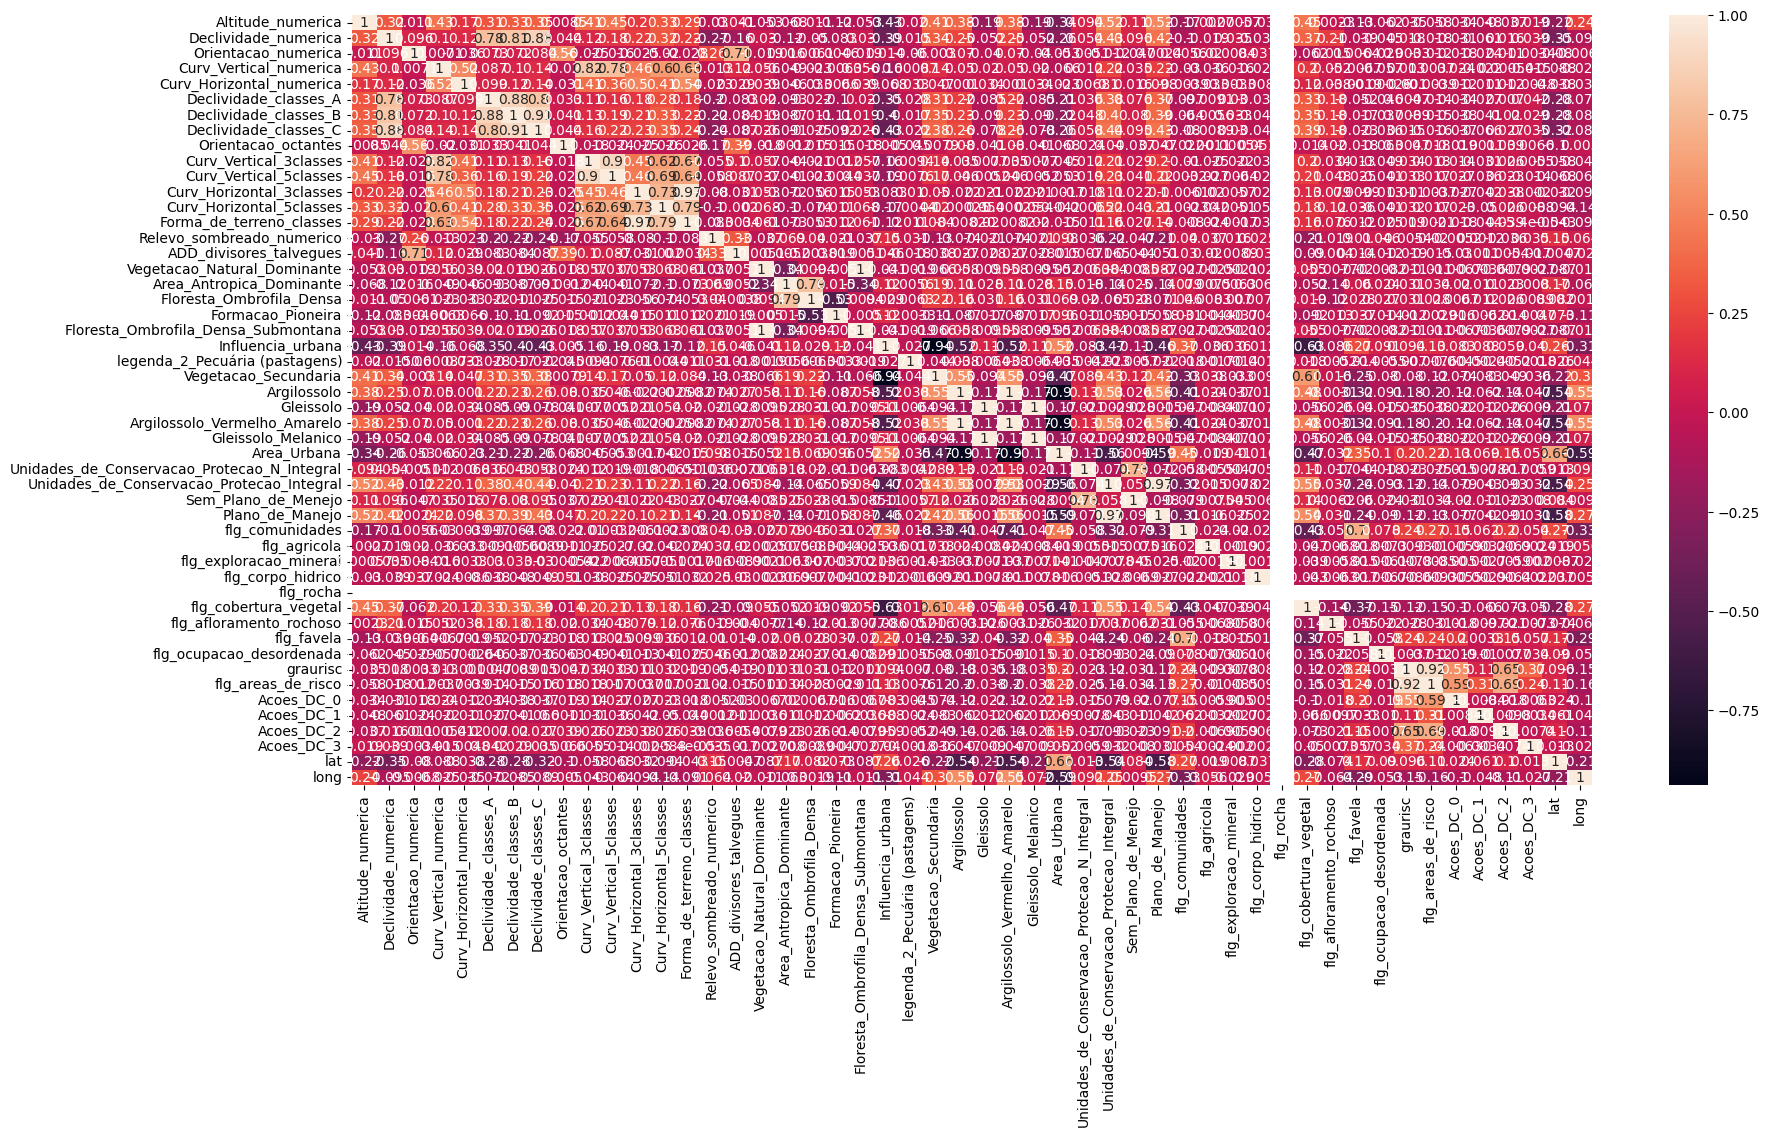

In [19]:
plt.figure(figsize = (20,10))
sns.heatmap(df.corr(), annot = True)

var_columns_to_drop(df, 0.000001)

In [25]:
get_top_abs_correlations(df,30)

Gleissolo                                    Gleissolo_Melanico                     1.000000
Vegetacao_Natural_Dominante                  Floresta_Ombrofila_Densa_Submontana    1.000000
Argilossolo                                  Argilossolo_Vermelho_Amarelo           1.000000
Unidades_de_Conservacao_Protecao_Integral    Plano_de_Manejo                        0.972867
Curv_Horizontal_3classes                     Forma_de_terreno_classes               0.965617
Influencia_urbana                            Vegetacao_Secundaria                   0.937810
graurisc                                     flg_areas_de_risco                     0.919570
Declividade_classes_B                        Declividade_classes_C                  0.905458
Argilossolo_Vermelho_Amarelo                 Area_Urbana                            0.901113
Argilossolo                                  Area_Urbana                            0.901113
Curv_Vertical_3classes                       Curv_Vertical_5classes   

In [26]:
df.drop(columns = [
    # Pela variância
'flg_rocha'
    # Pela correlação
, 'Argilossolo_Vermelho_Amarelo'
, 'Curv_Horizontal_5classes'
, 'Curv_Vertical_3classes'
, 'Curv_Vertical_5classes'
, 'Declividade_classes_A'
, 'Declividade_classes_B'
, 'Declividade_classes_C'
, 'flg_areas_de_risco'
, 'Floresta_Ombrofila_Densa'
, 'Floresta_Ombrofila_Densa_Submontana'
, 'Forma_de_terreno_classes'
, 'Plano_de_Manejo'
, 'Sem_Plano_de_Menejo'
, 'Vegetacao_Secundaria'
, 'Gleissolo_Melanico'
, 'ADD_divisores_talvegues'
, 'Argilossolo'
, 'Curv_Horizontal_3classes'
, 'Unidades_de_Conservacao_Protecao_N_Integral'], inplace = True)

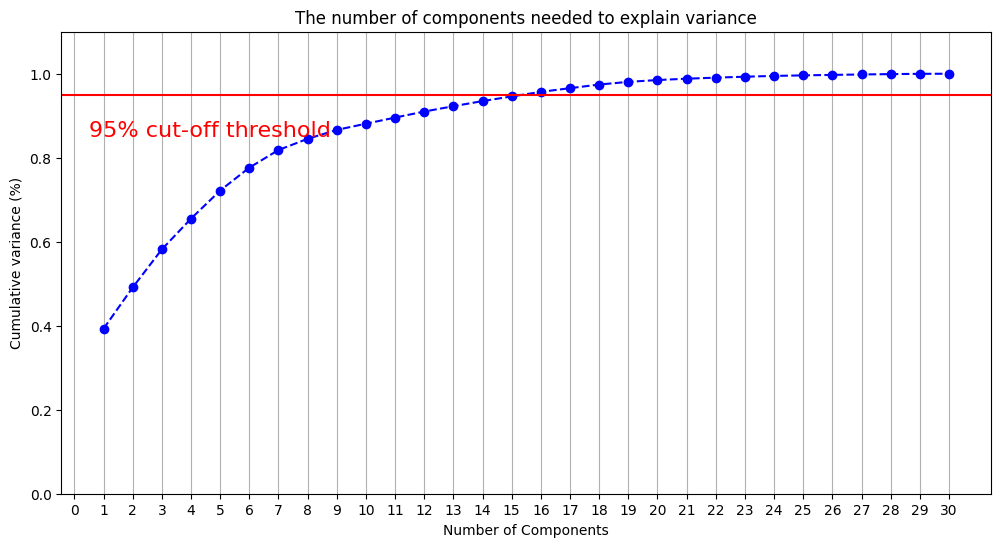

In [30]:
PCA_explicabilidade(df, seed = 42)

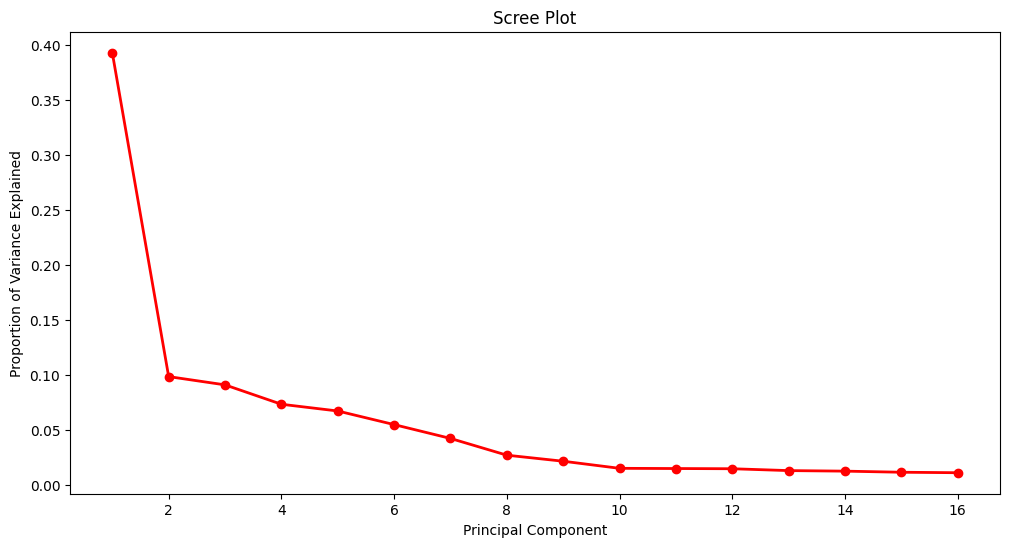

In [32]:
PCA_elbow(df, componentes = 16, seed = 42)

In [37]:
# 2 fatores
fa = FactorAnalyzer( 2, rotation="varimax")

# o objeto tem o método fit para análise do dataframe
fa.fit(df)

# Desse extraimos as cargas fatoriais (factor loadings)
# Observe que fa.loadings_ é um numpy.array com shape (25,6). Usamos o método
# do pandas pd.DataFrame.from_records para convertê-lo em um dataframe
factorLoadings = pd.DataFrame.from_records(fa.loadings_)
# Para ver a dataframe gerado:
factorLoadings.head()
# Substitue as linhas pelo nomes dos itens
itens=df.columns
factorLoadings.index=itens

# Renomeia as colunas
factorLoadings.rename(columns = {0:'Fator 1',
                                 1:'Fator 2',
                                }, inplace = True)

# Exibe o resultado
factorLoadings

,Fator 1,Fator 2
Altitude_numerica,0.616550,0.019548
Declividade_numerica,0.539252,0.113605
Orientacao_numerica,0.010082,-0.000240
Curv_Vertical_numerica,0.330859,0.144803
Curv_Horizontal_numerica,0.207238,0.120626
Orientacao_octantes,0.060826,0.008189
Relevo_sombreado_numerico,-0.239056,-0.061382
Vegetacao_Natural_Dominante,0.084795,-0.005460
Area_Antropica_Dominante,-0.180877,0.034410
Formacao_Pioneira,-0.132432,0.013566


* Fator 1 :
        Altitude_numerica
        Declividade_numerica
        Influencia_urbana
        Area_Urbana
        Unidades_de_Conservacao_Protecao_Integral
        flg_cobertura_vegetal
        lat
Caracteristicas Geologicas e Urbanização



* Fator 2 :
        flg_comunidades
        flg_favela
        graurisc
Caracteristicas Urbanização

In [39]:
pca= PCA()
principalComponents = pca.fit_transform(df)
N_COMPONENTS = 2
pca_cols = ["PC%d" %i for i in range(1, N_COMPONENTS+1)]
df_pca = pd.DataFrame(principalComponents[:,:N_COMPONENTS], columns=pca_cols)
df_pca

,PC1,PC2
0,-1.072022,-0.358233
1,-1.087276,-0.313595
2,-1.040853,-0.202882
3,-1.006532,-0.158572
4,-1.155979,-0.051458
...,...,...
3130,0.311486,0.000720
3131,0.907710,-0.947487
3132,1.284190,-0.414575
3133,0.964695,-0.637851


# Clusterização

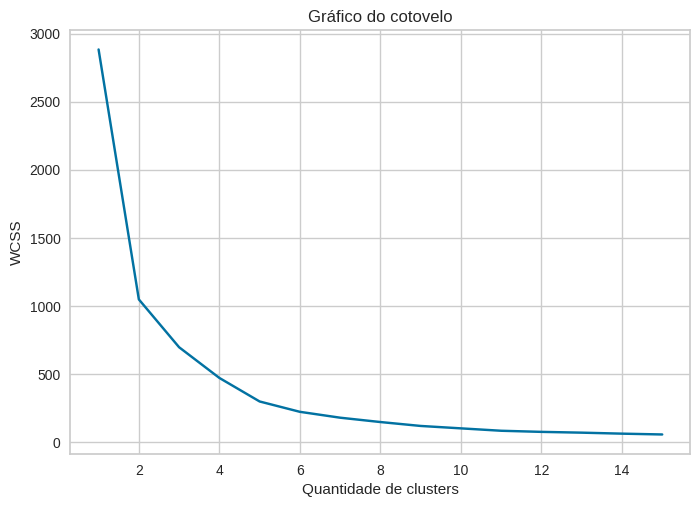

In [47]:
elbow_kmeans(df_pca,16)

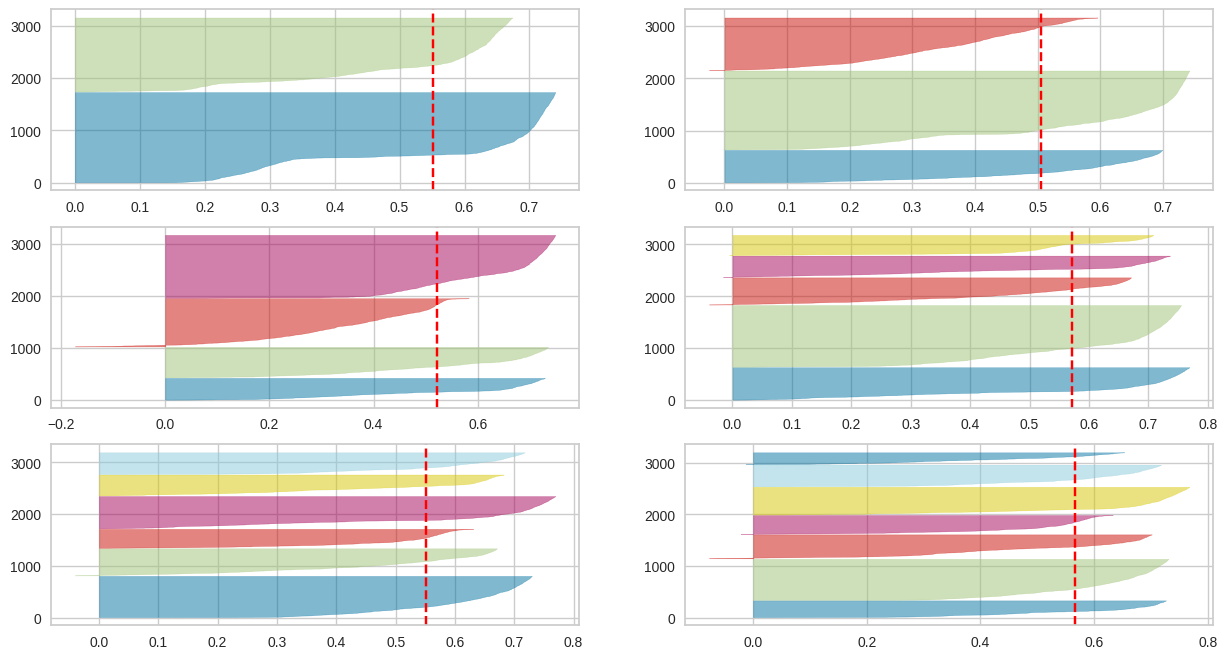

In [48]:
fig, ax = plt.subplots(3, 2, figsize=(15,8))
for i in [2, 3, 4, 5, 6, 7]:
    '''
    Create KMeans instance for different number of clusters
    '''
    km = KMeans(n_clusters=i, init='k-means++', n_init=10, max_iter=100, random_state=42)
    q, mod = divmod(i, 2)
    '''
    Create SilhouetteVisualizer instance with KMeans instance
    Fit the visualizer
    '''
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick', ax=ax[q-1][mod])
    visualizer.fit(df_pca)

De 5 a 7 Clusters.

Sendo que o ideal parece ser com 6 clusters, sendo válido testar com 2.

In [53]:
Clust_kmeans_pca2 = KMeans(n_clusters=2, init ='k-means++', max_iter=300, n_init=100,random_state=42 )
Clust_kmeans_pca2.fit(df_pca)
Clust_kmeans_pca2_labels = Clust_kmeans_pca2.predict(df_pca)

In [66]:
df_raw['Cluster_2'] = Clust_kmeans_pca2_labels

In [67]:
df_raw['Cluster_2'].to_csv('coord_cluster_2.csv')

In [51]:
Clust_kmeans_pca5 = KMeans(n_clusters=5, init ='k-means++', max_iter=300, n_init=100,random_state=42 )
Clust_kmeans_pca5.fit(df_pca)
Clust_kmeans_pca5_labels = Clust_kmeans_pca5.predict(df_pca)

In [60]:
df_raw['Cluster_5'] = Clust_kmeans_pca5_labels

In [68]:
df_raw['Cluster_5'].to_csv('coord_cluster_5.csv')

In [54]:
Clust_kmeans_pca6 = KMeans(n_clusters=6, init ='k-means++', max_iter=300, n_init=100,random_state=42 )
Clust_kmeans_pca6.fit(df_pca)
Clust_kmeans_pca6_labels = Clust_kmeans_pca6.predict(df_pca)

In [61]:
df_raw['Cluster_6'] = Clust_kmeans_pca6_labels

In [69]:
df_raw['Cluster_6'].to_csv('coord_cluster_6.csv')

In [55]:
Clust_kmeans_pca7 = KMeans(n_clusters=7, init ='k-means++', max_iter=300, n_init=100,random_state=42 )
Clust_kmeans_pca7.fit(df_pca)
Clust_kmeans_pca7_labels = Clust_kmeans_pca7.predict(df_pca)

In [70]:
df_raw['Cluster_7'] = Clust_kmeans_pca7_labels

In [71]:
df_raw['Cluster_7'].to_csv('coord_cluster_7.csv')

In [ ]:
#df['Cluster'].to_csv('coord_cluster_6.csv')